# Melanoma Classificafier

In [ ]:
# Install any missing packages
# !pip install torchvision -q

import sys
print(f"Python {sys.version}")

import torch, torchvision
print(f"PyTorch {torch.__version__}")
print(f"Torchvision {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

In [ ]:
# Choose where to save outputs
import os
OUTPUT_DIR = '/AML_Project/outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Outputs will be saved to: {OUTPUT_DIR}")

## Imports

In [3]:
import os
import time
import math
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import models, transforms
from torchvision.ops import sigmoid_focal_loss
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torch.nn.functional as F

from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve, 
    precision_recall_curve
)

from IPython.display import clear_output, display


# =========================================================
# Reproducibility
# =========================================================
SEED = 42

def seed_everything(seed: int = 42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

    torch.use_deterministic_algorithms(True, warn_only=False)

    if torch.cuda.is_available():
        torch.backends.cuda.enable_flash_sdp(False)
        torch.backends.cuda.enable_mem_efficient_sdp(False)
        torch.backends.cuda.enable_math_sdp(True)

seed_everything(SEED)

def seed_worker(worker_id: int):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

def make_loader_generator(seed_offset: int):
    g = torch.Generator()
    g.manual_seed(SEED + seed_offset)
    return g

print(f"Python: {os.sys.version}")
print(f"PyTorch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"SEED: {SEED}")

Python: 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
PyTorch: 2.6.0+cu124
Torchvision: 0.21.0+cu124
CUDA available: True
GPU: NVIDIA RTX A4000
SEED: 42


## Data paths

In [ ]:
import os
import zipfile

zip_path = '/AML_Project/JPEG Melanoma 224x224.zip'
data_path = '/AML_Project/inputs/siim_isic_224'
extract_path = '/AML_Project/inputs/'

if not os.path.exists(data_path) or len(os.listdir(data_path)) == 0:
    print("Extracting dataset...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)
else:
    print("Dataset already extracted. Skipping.")



Dataset already extracted. Skipping.


In [ ]:
# ── Data paths ──────────────────────
DATA_DIR  = Path("/AML_Project/inputs/siim_isic_224")   # root folder of the dataset
CSV_PATH  = DATA_DIR / "train_resized_224.csv"
IMAGE_DIR = DATA_DIR / "train"
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)

COLUMNS = ["image_name", "patient_id", "sex", "age_approx", "anatom_site_general_challenge", "diagnosis",
        "benign_malignant", "target", "resized_path"]
df = df[COLUMNS].copy()

df["image_path"] = str(IMAGE_DIR) + "/" + df["image_name"] + ".jpg"

print("--- Dataset Overview ---")
print(df.head())
print(f"\nColumns: {list(df.columns)}")
print(f"Total rows: {len(df)}")
print(f"Unique patients: {df['patient_id'].nunique()}")
print(f"Missing patient IDs: {df['patient_id'].isna().sum()}")

--- Dataset Overview ---
     image_name  patient_id     sex  age_approx anatom_site_general_challenge  \
0  ISIC_2637011  IP_7279968    male        45.0                     head/neck   
1  ISIC_0015719  IP_3075186  female        45.0               upper extremity   
2  ISIC_0052212  IP_2842074  female        50.0               lower extremity   
3  ISIC_0068279  IP_6890425  female        45.0                     head/neck   
4  ISIC_0074268  IP_8723313  female        55.0               upper extremity   

  diagnosis benign_malignant  target  \
0   unknown           benign       0   
1   unknown           benign       0   
2     nevus           benign       0   
3   unknown           benign       0   
4   unknown           benign       0   

                                        resized_path  \
0  /kaggle/working/siim_isic_224/train/ISIC_26370...   
1  /kaggle/working/siim_isic_224/train/ISIC_00157...   
2  /kaggle/working/siim_isic_224/train/ISIC_00522...   
3  /kaggle/working/siim

## Sanity check — peek at one image

Sample image path: /user/HS401/ep01372/Documents/AML_Project/inputs/siim_isic_224/train/ISIC_2637011.jpg
Label (0=benign, 1=melanoma): 0
Image dimensions: (224, 224)


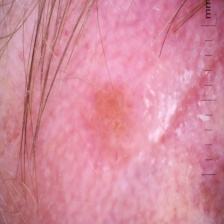

In [6]:
sample_image_path = df.loc[0, "image_path"]
sample_label = df.loc[0, "target"]

print(f"Sample image path: {sample_image_path}")
print(f"Label (0=benign, 1=melanoma): {sample_label}")

sample_image = Image.open(sample_image_path).convert("RGB")
print(f"Image dimensions: {sample_image.size}")
sample_image

## Train / Validation split (patient-level)

In [7]:
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS = 3
FOLDS_TO_RUN = [0, 1, 2]
RANDOM_STATE = SEED

df = df.sort_values("image_name").reset_index(drop=True)

cv_splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

fold_splits = []
for fold, (train_idx, val_idx) in enumerate(
    cv_splitter.split(df, df["target"], groups=df["patient_id"])
):
    if fold in FOLDS_TO_RUN:
        fold_splits.append((fold, train_idx, val_idx))

print(f"Prepared folds: {FOLDS_TO_RUN}")

Prepared folds: [0, 1, 2]


## Dataset class

In [8]:
class MelanomaDataset(Dataset):
    """Custom PyTorch Dataset for binary melanoma classification."""

    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = torch.tensor(row["target"], dtype=torch.float32)
        if self.transform is not None:
            image = self.transform(image)
        return image, label

## DataLoaders

In [9]:
TRAIN_BATCH_SIZE = 64
VAL_BATCH_SIZE   = 256
NUM_WORKERS      = 4

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10,
        hue=0.02
    ),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

def make_train_loader(train_df, fold_idx):
    train_dataset = MelanomaDataset(train_df, transform=train_transform)
    loader_generator = make_loader_generator(1000 + fold_idx)

    if imbalance_strategy == "weighted_sampler":
        labels = train_df["target"].values.astype(int)
        class_counts = np.bincount(labels)
        class_weights = 1.0 / class_counts
        sample_weights = class_weights[labels]
        sample_weights = torch.as_tensor(sample_weights, dtype=torch.double)

        sampler_generator = make_loader_generator(3000 + fold_idx)

        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True,
            generator=sampler_generator
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=TRAIN_BATCH_SIZE,
            sampler=sampler,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            persistent_workers=(NUM_WORKERS > 0),
            worker_init_fn=seed_worker,
            generator=loader_generator,
        )
    else:
        train_loader = DataLoader(
            train_dataset,
            batch_size=TRAIN_BATCH_SIZE,
            shuffle=True,
            num_workers=NUM_WORKERS,
            pin_memory=torch.cuda.is_available(),
            persistent_workers=(NUM_WORKERS > 0),
            worker_init_fn=seed_worker,
            generator=loader_generator,
        )

    return train_loader

def make_val_loader(val_df, fold_idx):
    val_dataset = MelanomaDataset(val_df, transform=val_transform)
    loader_generator = make_loader_generator(2000 + fold_idx)

    val_loader = DataLoader(
        val_dataset,
        batch_size=VAL_BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
        persistent_workers=(NUM_WORKERS > 0),
        worker_init_fn=seed_worker,
        generator=loader_generator,
    )
    return val_loader

## Model — EfficientNet-B0

In [10]:
class MelanomaClassifier(nn.Module):
    """
    EfficientNet-B0 adapted for binary melanoma classification.
    The 1000-class head is replaced with a single linear neuron
    that outputs one logit for BCEWithLogitsLoss / Focal Loss.
    """

    def __init__(self, weights_path=None):
        super().__init__()

        if weights_path and Path(weights_path).exists():
            # --- Offline weights ---
            self.model = models.efficientnet_b0(weights=None)
            state_dict = torch.load(weights_path, map_location='cpu', weights_only=True)
            self.model.load_state_dict(state_dict)
            print(f"Loaded offline weights from {weights_path}")
        else:
            # --- Download from torchvision (requires internet) ---
            self.model = models.efficientnet_b0(weights='IMAGENET1K_V1')
            print("Downloaded ImageNet weights from torchvision")

        # Replace 1000-class head with binary head
        in_features = self.model.classifier[1].in_features
        self.model.classifier[1] = nn.Linear(in_features, 1)

    def forward(self, x):
        return self.model(x)

## Model custom CNN–ViT hybrid

In [11]:
class MelanomaResidualGatedHybridClassifier(nn.Module):
    """
    Residual gated EfficientNet-B0 + Transformer hybrid.

    Main path:
        cnn_logit = EfficientNet-B0 full classifier logit

    Residual path:
        CNN feature map -> 1x1 projection -> Transformer -> transformer_logit

    Final:
        final_logit = cnn_logit + sigmoid(gate_logit) * transformer_logit
    """

    def __init__(
        self,
        weights_path=None,
        transfer_model_path=None,
        embed_dim=384,
        num_heads=6,
        depth=4,
        mlp_ratio=4.0,
        dropout=0.10,
        gate_init=-2.0,
    ):
        super().__init__()

        cnn_wrapper = MelanomaClassifier(weights_path=weights_path)

        if transfer_model_path and Path(transfer_model_path).exists():
            state_dict = torch.load(
                transfer_model_path,
                map_location="cpu",
                weights_only=True
            )
            cnn_wrapper.load_state_dict(state_dict)
            print(f"Loaded baseline CNN checkpoint from {transfer_model_path}")

        self.cnn_model = cnn_wrapper.model
        self.cnn_out_channels = 1280

        self.token_projection = nn.Conv2d(
            in_channels=self.cnn_out_channels,
            out_channels=embed_dim,
            kernel_size=1,
            stride=1,
            padding=0,
            bias=True,
        )

        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.depth = depth
        self.mlp_ratio = mlp_ratio

        # EfficientNet-B0 at 224x224 produces a 7x7 feature map -> 49 tokens
        self.num_tokens = 7 * 7
        self.pos_embed = nn.Parameter(torch.zeros(1, self.num_tokens, embed_dim))
        self.pos_drop = nn.Dropout(dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer=encoder_layer,
            num_layers=depth,
        )

        self.transformer_norm = nn.LayerNorm(embed_dim)
        self.transformer_head = nn.Linear(embed_dim, 1)

        # Scalar learnable residual gate.
        # sigmoid(-2.0) ≈ 0.119, so the model starts close to the CNN baseline.
        self.gate_logit = nn.Parameter(torch.tensor(float(gate_init)))

        self._init_new_weights()

    def _init_new_weights(self):
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        nn.init.kaiming_normal_(
            self.token_projection.weight,
            mode="fan_out",
            nonlinearity="relu"
        )
        if self.token_projection.bias is not None:
            nn.init.zeros_(self.token_projection.bias)

        nn.init.trunc_normal_(self.transformer_head.weight, std=0.02)
        nn.init.zeros_(self.transformer_head.bias)

    def set_cnn_trainable(self, trainable):
        self.cnn_trainable = trainable

        for param in self.cnn_model.parameters():
            param.requires_grad = trainable

        if trainable:
            self.cnn_model.train()
        else:
            self.cnn_model.eval()

    def enforce_frozen_cnn_eval(self):
        if not getattr(self, "cnn_trainable", True):
            self.cnn_model.eval()

    def get_cnn_parameters(self):
        return self.cnn_model.parameters()

    def get_new_parameters(self):
        modules = [
            self.token_projection,
            self.transformer,
            self.transformer_norm,
            self.transformer_head,
        ]

        for module in modules:
            for param in module.parameters():
                yield param

        yield self.pos_embed
        yield self.gate_logit

    def forward(self, x):
        features = self.cnn_model.features(x)              # [B, 1280, 7, 7]

        pooled = self.cnn_model.avgpool(features)          # [B, 1280, 1, 1]
        pooled = torch.flatten(pooled, 1)                  # [B, 1280]
        cnn_logit = self.cnn_model.classifier(pooled)      # [B, 1]

        tokens = self.token_projection(features)           # [B, embed_dim, 7, 7]
        tokens = tokens.flatten(2).transpose(1, 2)         # [B, 49, embed_dim]

        tokens = tokens + self.pos_embed
        tokens = self.pos_drop(tokens)

        tokens = self.transformer(tokens)                  # [B, 49, embed_dim]
        tokens = tokens.mean(dim=1)                        # [B, embed_dim]
        tokens = self.transformer_norm(tokens)

        transformer_logit = self.transformer_head(tokens)  # [B, 1]

        gate = torch.sigmoid(self.gate_logit)
        final_logit = cnn_logit + gate * transformer_logit

        return final_logit

## Model setup

In [ ]:

PRETRAINED_WEIGHTS_PATH = '/user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth'

TRANSFER_MODEL_PATHS_BY_FOLD = {
    0: "/AML_Project/inputs/efficientnet_b0_transfer_full_ft_FOCAL_alpha_075_3fold_TTA_AUPRC_30epochs_aug_fold_0_best_model.pth",
    1: "/AML_Project/inputs/efficientnet_b0_transfer_full_ft_FOCAL_alpha_075_3fold_TTA_AUPRC_30epochs_aug_fold_1_best_model.pth",
    2: "/AML_Project/inputs/efficientnet_b0_transfer_full_ft_FOCAL_alpha_075_3fold_TTA_AUPRC_30epochs_aug_fold_2_best_model.pth",
}

FROZEN_HYBRID_PATHS_BY_FOLD = {
    0: "/AML_Project/inputs/efficientNet_b0_custom_transferKaggleCNN_ViT_hybrid_frozenCNN_3folds_OOF_AUPRC_v0_fold_0_best_model.pth",
    1: "/AML_Project/inputs/efficientNet_b0_custom_transferKaggleCNN_ViT_hybrid_frozenCNN_3folds_OOF_AUPRC_v0_fold_1_best_model.pth",
    2: "/AML_Project/inputs/efficientNet_b0_custom_transferKaggleCNN_ViT_hybrid_frozenCNN_3folds_OOF_AUPRC_v0_fold_2_best_model.pth",
}



TRANSFER_MODEL_PATH_ALL_DEV = "/path/to/kaggle_cnn_all_dev_best_model.pth"

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)



def build_model(
    fold_idx=None,
    use_all_dev_checkpoint=False,
    warmstart_hybrid_from_frozen=False,
):
    if warmstart_hybrid_from_frozen:
        raise ValueError(
            "Do not use warmstart_hybrid_from_frozen=True with the residual/gated hybrid. "
            "Previous hybrid checkpoints have a different architecture."
        )

    if use_all_dev_checkpoint:
        transfer_model_path = TRANSFER_MODEL_PATH_ALL_DEV
    else:
        if fold_idx is None:
            raise ValueError("fold_idx must be provided when use_all_dev_checkpoint=False")
        transfer_model_path = TRANSFER_MODEL_PATHS_BY_FOLD[fold_idx]

    model = MelanomaResidualGatedHybridClassifier(
        weights_path=PRETRAINED_WEIGHTS_PATH,
        transfer_model_path=transfer_model_path,
        embed_dim=HYBRID_EMBED_DIM,
        num_heads=HYBRID_NUM_HEADS,
        depth=HYBRID_DEPTH,
        mlp_ratio=HYBRID_MLP_RATIO,
        dropout=HYBRID_DROPOUT,
        gate_init=RESIDUAL_GATE_INIT,
    )

    if TRAINING_STAGE == "frozen":
        model.set_cnn_trainable(False)
    elif TRAINING_STAGE == "full_fine":
        model.set_cnn_trainable(True)
    else:
        raise ValueError(f"Invalid TRAINING_STAGE: {TRAINING_STAGE}")

    model = model.to(device)
    return model



Device: cuda:0


## Loss function & optimiser

In [13]:

# --- Residual gated hybrid v1 ---
TRAINING_STAGE = "full_fine"   # "frozen" or "full_fine"

FOCAL_ALPHA = 0.75
FOCAL_GAMMA = 2.0

HYBRID_EMBED_DIM = 384
HYBRID_NUM_HEADS = 6
HYBRID_DEPTH = 4
HYBRID_MLP_RATIO = 4.0
HYBRID_DROPOUT = 0.10
HYBRID_ATTN_DROPOUT = 0.00

RESIDUAL_GATE_INIT = -3.0

FROZEN_LR = 3e-4
FROZEN_WEIGHT_DECAY = 0.05

FULL_FINE_CNN_LR = 1e-5
FULL_FINE_NEW_LR = 5e-5
FULL_FINE_WEIGHT_DECAY = 0.05





class BinaryFocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        targets = targets.float()

        ce_loss = F.binary_cross_entropy_with_logits(
            inputs,
            targets,
            reduction="none"
        )

        p = torch.sigmoid(inputs)
        p_t = p * targets + (1 - p) * (1 - targets)

        loss = ce_loss * ((1 - p_t) ** self.gamma)

        if self.alpha >= 0:
            alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
            loss = alpha_t * loss

        if self.reduction == "mean":
            return loss.mean()
        elif self.reduction == "sum":
            return loss.sum()
        elif self.reduction == "none":
            return loss
        else:
            raise ValueError(f"Invalid reduction: {self.reduction}")


def build_training_components(model, train_df):
    criterion = BinaryFocalLoss(
        alpha=FOCAL_ALPHA,
        gamma=FOCAL_GAMMA,
        reduction="mean"
    ).to(device)

    if TRAINING_STAGE == "frozen":
        optimiser = optim.AdamW(
            [
                {
                    "name": "trainable",
                    "params": [p for p in model.parameters() if p.requires_grad],
                    "lr": FROZEN_LR,
                    "weight_decay": FROZEN_WEIGHT_DECAY,
                }
            ]
        )

    elif TRAINING_STAGE == "full_fine":
        optimiser = optim.AdamW(
            [
                {
                    "name": "cnn",
                    "params": [p for p in model.get_cnn_parameters() if p.requires_grad],
                    "lr": FULL_FINE_CNN_LR,
                    "weight_decay": FULL_FINE_WEIGHT_DECAY,
                },
                {
                    "name": "new",
                    "params": [p for p in model.get_new_parameters() if p.requires_grad],
                    "lr": FULL_FINE_NEW_LR,
                    "weight_decay": FULL_FINE_WEIGHT_DECAY,
                },
            ]
        )

    else:
        raise ValueError(f"Invalid TRAINING_STAGE: {TRAINING_STAGE}")

    return criterion, optimiser





In [14]:
def summarize_trainable_parameters(model):
    cnn_total = 0
    cnn_trainable = 0

    for param in model.get_cnn_parameters():
        n = param.numel()
        cnn_total += n
        if param.requires_grad:
            cnn_trainable += n

    new_total = 0
    new_trainable = 0

    for param in model.get_new_parameters():
        n = param.numel()
        new_total += n
        if param.requires_grad:
            new_trainable += n

    print(f"CNN trainable params: {cnn_trainable:,} out of {cnn_total:,}")
    print(f"New trainable params: {new_trainable:,} out of {new_total:,}")

    if TRAINING_STAGE == "frozen":
        assert cnn_trainable == 0, "CNN should be frozen, but some CNN params are trainable."
        assert new_trainable > 0, "New hybrid params should be trainable."

    elif TRAINING_STAGE == "full_fine":
        assert cnn_trainable > 0, "CNN should be trainable in full_fine stage."
        assert new_trainable > 0, "New hybrid params should be trainable."

    else:
        raise ValueError(f"Invalid TRAINING_STAGE: {TRAINING_STAGE}")

In [15]:
def get_residual_gate_value(model):
    if not hasattr(model, "gate_logit"):
        return np.nan

    with torch.no_grad():
        gate = torch.sigmoid(model.gate_logit.detach()).item()

    return float(gate)


def get_residual_gate_logit_value(model):
    if not hasattr(model, "gate_logit"):
        return np.nan

    with torch.no_grad():
        gate_logit = model.gate_logit.detach().item()

    return float(gate_logit)


def get_optimizer_lr_summary(optimiser):
    lr_summary = {}

    for idx, group in enumerate(optimiser.param_groups):
        group_name = group.get("name", f"group_{idx}")
        lr_summary[f"{group_name}_lr"] = float(group["lr"])
        lr_summary[f"{group_name}_weight_decay"] = float(group.get("weight_decay", 0.0))

    return lr_summary


def format_optimizer_lr_summary(optimiser):
    lr_summary = get_optimizer_lr_summary(optimiser)

    parts = []
    for key, value in lr_summary.items():
        if key.endswith("_lr"):
            parts.append(f"{key}: {value:.8f}")
        elif key.endswith("_weight_decay"):
            parts.append(f"{key}: {value:.6f}")

    return " | ".join(parts)

## Experiment setup — output paths & logging

In [16]:
imbalance_strategy = None   # "pos_weight" or "weighted_sampler"


EXPERIMENT_NAME = "efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1"

WORKING_DIR = Path(OUTPUT_DIR)
WORKING_DIR.mkdir(parents=True, exist_ok=True)

def get_fold_paths(fold_idx):
    best_model_path      = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_best_model.pth"
    last_checkpoint_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_last_checkpoint.pth"
    log_path             = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_training_log.txt"
    return best_model_path, last_checkpoint_path, log_path

def log_message(message, log_path, printing=False):
    if printing:
        print(message)
    with open(log_path, "a") as f:
        f.write(message + "\n")

## Training & validation functions

In [17]:
def apply_tta_transforms(images):
    """
    8x D4 TTA for NCHW tensors.

    images shape: [B, C, H, W]
    """
    return [
        images,                                      # identity
        torch.flip(images, dims=[3]),                # hflip
        torch.flip(images, dims=[2]),                # vflip
        torch.flip(images, dims=[2, 3]),             # hflip + vflip
        torch.rot90(images, k=1, dims=[2, 3]),       # rot90
        torch.flip(torch.rot90(images, k=1, dims=[2, 3]), dims=[3]),  # rot90 + hflip
        torch.rot90(images, k=2, dims=[2, 3]),       # rot180
        torch.rot90(images, k=3, dims=[2, 3]),       # rot270
    ]

In [18]:
def train_one_epoch(model, dataloader, criterion, optimiser, device, log_path=None):
    model.train()

    if hasattr(model, "enforce_frozen_cnn_eval"):
        model.enforce_frozen_cnn_eval()

    running_loss = correct = total = 0
    epoch_start = time.perf_counter()
    all_probs, all_labels = [], []

    for batch_idx, (images, labels) in enumerate(dataloader, start=1):
        images = images.to(device, non_blocking=True)
        labels = labels.unsqueeze(1).to(device, non_blocking=True)

        optimiser.zero_grad(set_to_none=True)
        logits = model(images)
        loss   = criterion(logits, labels)
        loss.backward()
        optimiser.step()

        probs      = torch.sigmoid(logits)
        pred       = (probs >= 0.5).float()

        bs         = images.size(0)
        running_loss += loss.item() * bs
        correct      += (pred == labels).sum().item()
        total        += bs

        all_probs.extend(probs.squeeze(1).detach().cpu().numpy())
        all_labels.extend(labels.squeeze(1).detach().cpu().numpy())

        if (batch_idx % 10 == 0 or batch_idx == len(dataloader)) and log_path is not None: 
            elapsed = time.perf_counter() - epoch_start
            log_message(
                f"Train [{batch_idx}/{len(dataloader)}] "
                f"Loss: {running_loss/total:.4f} "
                f"Acc: {correct/total:.4f} "
                f"Elapsed: {elapsed:.1f}s",
                log_path=log_path,
                printing=False
            )

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    return {
        "loss":     running_loss / total,
        "accuracy": correct / total,
        "auroc":    roc_auc_score(all_labels, all_probs),
        "auprc": average_precision_score(all_labels, all_probs),
    }


def validate_one_epoch(model, dataloader, criterion, device, use_tta=False, log_path=None):
    model.eval()
    running_loss = correct = total = 0
    epoch_start = time.perf_counter()
    all_probs, all_labels, all_preds = [], [], []

    with torch.no_grad():
        for batch_idx, (images, labels) in enumerate(dataloader, start=1):
            images = images.to(device, non_blocking=True)
            labels = labels.unsqueeze(1).to(device, non_blocking=True)


            if use_tta:
                tta_images = apply_tta_transforms(images)

                tta_losses = []
                tta_probs = []

                for aug_images in tta_images:
                    logits_aug = model(aug_images)
                    loss_aug = criterion(logits_aug, labels)
                    probs_aug = torch.sigmoid(logits_aug)

                    tta_losses.append(loss_aug)
                    tta_probs.append(probs_aug)

                loss = torch.stack(tta_losses).mean()
                probs = torch.stack(tta_probs, dim=0).mean(dim=0)

            else:
                logits = model(images)
                loss = criterion(logits, labels)
                probs = torch.sigmoid(logits)

            
        
            pred   = (probs >= 0.5).float()

            bs     = images.size(0)
            running_loss += loss.item() * bs
            correct      += (pred == labels).sum().item()
            total        += bs

            all_probs.extend(probs.squeeze(1).cpu().numpy())
            all_labels.extend(labels.squeeze(1).cpu().numpy())
            all_preds.extend(pred.squeeze(1).cpu().numpy())

            if batch_idx % 10 == 0 or batch_idx == len(dataloader):
                elapsed = time.perf_counter() - epoch_start
                if log_path is not None:
                    log_message(
                        f"Val [{batch_idx}/{len(dataloader)}] "
                        f"Loss: {running_loss/total:.4f} "
                        f"Acc: {correct/total:.4f} "
                        f"Elapsed: {elapsed:.1f}s",
                        log_path=log_path,
                        printing=False
                    )

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "loss": running_loss / total,
        "accuracy": correct / total,
        "auroc": roc_auc_score(all_labels, all_probs),
        "auprc": average_precision_score(all_labels, all_probs),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0),
        "specificity": specificity,
        "confusion_matrix": cm,
        "all_probs": all_probs,
        "all_labels": all_labels,
        "all_preds": all_preds,
    }

In [19]:
def threshold_sweep(y_true, y_prob, thresholds=np.arange(0.05, 0.96, 0.05)):
    results = []

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()

        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

        results.append({
            "threshold": float(thr),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "recall": recall_score(y_true, y_pred, zero_division=0),
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "specificity": specificity,
        })

    return pd.DataFrame(results)

## Training loop

In [20]:
num_epochs = 15
USE_TTA = False
checkpoint_metric = "auprc"   # "auroc" or "auprc"
WARMSTART_HYBRID = False

all_fold_results = []

full_training_start = time.perf_counter()

for fold_idx, train_idx, val_idx in fold_splits:
    print(f"\n===== Fold {fold_idx} =====")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df = df.iloc[val_idx].reset_index(drop=True)

    print(f"Train size: {len(train_df)} | positives: {int(train_df['target'].sum())}")
    print(f"Val size:   {len(val_df)} | positives: {int(val_df['target'].sum())}")

    train_loader = make_train_loader(train_df, fold_idx=fold_idx)
    val_loader = make_val_loader(val_df, fold_idx=fold_idx)

    model = build_model(
        fold_idx=fold_idx,
        use_all_dev_checkpoint=False,
        warmstart_hybrid_from_frozen=WARMSTART_HYBRID,
    )

    summarize_trainable_parameters(model)

    criterion, optimiser = build_training_components(model, train_df)

    initial_gate = get_residual_gate_value(model)
    initial_gate_logit = get_residual_gate_logit_value(model)
    optimizer_summary = format_optimizer_lr_summary(optimiser)

    print(f"Initial residual gate: {initial_gate:.6f} | gate_logit: {initial_gate_logit:.6f}")
    print(f"Optimizer groups: {optimizer_summary}")

    BEST_MODEL_PATH, LAST_CHECKPOINT_PATH, LOG_PATH = get_fold_paths(fold_idx)

    with open(LOG_PATH, "w") as f:
        f.write(f"Training log started at {datetime.now()}\n")
        f.write(f"TRAINING_STAGE: {TRAINING_STAGE}\n")
        f.write(f"RESIDUAL_GATE_INIT: {RESIDUAL_GATE_INIT}\n")
        f.write(f"Initial residual gate: {initial_gate:.6f}\n")
        f.write(f"Initial residual gate_logit: {initial_gate_logit:.6f}\n")
        f.write(f"Optimizer groups: {optimizer_summary}\n\n")

    best_val_metric = -1.0
    best_epoch = -1
    best_gate = np.nan
    best_gate_logit = np.nan

    fold_history = {
        "epoch": [],
        "train_loss": [],
        "val_loss": [],
        "train_auroc": [],
        "val_auroc": [],
        "val_auprc": [],
        "val_f1": [],
        "gate": [],
        "gate_logit": [],
        "cnn_lr": [],
        "new_lr": [],
        "cnn_weight_decay": [],
        "new_weight_decay": [],
    }

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()

        lr_summary_text = format_optimizer_lr_summary(optimiser)

        current_gate = get_residual_gate_value(model)
        current_gate_logit = get_residual_gate_logit_value(model)

        log_message(
            f"Starting epoch {epoch}/{num_epochs}... | "
            f"{lr_summary_text} | "
            f"gate: {current_gate:.6f} | gate_logit: {current_gate_logit:.6f}",
            log_path=LOG_PATH,
            printing=True
        )

        train_metrics = train_one_epoch(
            model,
            train_loader,
            criterion,
            optimiser,
            device,
            log_path=LOG_PATH
        )

        val_metrics = validate_one_epoch(
            model,
            val_loader,
            criterion,
            device,
            use_tta=USE_TTA,
            log_path=LOG_PATH
        )

        epoch_duration = time.perf_counter() - epoch_start

        epoch_gate = get_residual_gate_value(model)
        epoch_gate_logit = get_residual_gate_logit_value(model)
        epoch_lr_summary = get_optimizer_lr_summary(optimiser)

        fold_history["epoch"].append(epoch)
        fold_history["train_loss"].append(train_metrics["loss"])
        fold_history["val_loss"].append(val_metrics["loss"])
        fold_history["train_auroc"].append(train_metrics["auroc"])
        fold_history["val_auroc"].append(val_metrics["auroc"])
        fold_history["val_auprc"].append(val_metrics["auprc"])
        fold_history["val_f1"].append(val_metrics["f1"])
        fold_history["gate"].append(epoch_gate)
        fold_history["gate_logit"].append(epoch_gate_logit)
        fold_history["cnn_lr"].append(epoch_lr_summary.get("cnn_lr", np.nan))
        fold_history["new_lr"].append(epoch_lr_summary.get("new_lr", np.nan))
        fold_history["cnn_weight_decay"].append(epoch_lr_summary.get("cnn_weight_decay", np.nan))
        fold_history["new_weight_decay"].append(epoch_lr_summary.get("new_weight_decay", np.nan))

        log_message(
            f"Validation | Loss: {val_metrics['loss']:.4f} | Acc: {val_metrics['accuracy']:.4f} | "
            f"AUROC: {val_metrics['auroc']:.4f} | AUPRC: {val_metrics['auprc']:.4f} | "
            f"Precision: {val_metrics['precision']:.4f} | Recall: {val_metrics['recall']:.4f} | "
            f"Specificity: {val_metrics['specificity']:.4f} | F1: {val_metrics['f1']:.4f}",
            log_path=LOG_PATH,
            printing=True
        )

        cm = val_metrics["confusion_matrix"]
        tn, fp, fn, tp = cm.ravel()
        log_message(
            f"Confusion Matrix: TN={tn}  FP={fp}  FN={fn}  TP={tp}",
            log_path=LOG_PATH,
            printing=True
        )

        log_message(
            f"Epoch duration: {epoch_duration:.1f}s ({epoch_duration / 60:.2f} min)",
            log_path=LOG_PATH,
            printing=True
        )
        log_message("-" * 60, log_path=LOG_PATH, printing=True)

        current_metric = val_metrics[checkpoint_metric]

        if not math.isnan(current_metric) and current_metric > best_val_metric:
            best_val_metric = current_metric
            best_epoch = epoch
            best_gate = epoch_gate
            best_gate_logit = epoch_gate_logit

            torch.save(model.state_dict(), BEST_MODEL_PATH)

            log_message(
                f"Best model saved ({checkpoint_metric.upper()} {best_val_metric:.4f}) | "
                f"best_gate: {best_gate:.6f} | best_gate_logit: {best_gate_logit:.6f}",
                log_path=LOG_PATH,
                printing=True
            )

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimiser_state_dict": optimiser.state_dict(),
                "best_val_metric": best_val_metric,
                "best_epoch": best_epoch,
                "best_gate": best_gate,
                "best_gate_logit": best_gate_logit,
                "current_gate": epoch_gate,
                "current_gate_logit": epoch_gate_logit,
                "checkpoint_metric": checkpoint_metric,
                "lr_summary": epoch_lr_summary,
            },
            LAST_CHECKPOINT_PATH
        )

    history_df = pd.DataFrame(fold_history)
    history_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_history.csv"
    history_df.to_csv(history_path, index=False)

    print(
        f"Fold {fold_idx} best {checkpoint_metric.upper()}: {best_val_metric:.4f} "
        f"(epoch {best_epoch}) | best_gate: {best_gate:.6f} | best_gate_logit: {best_gate_logit:.6f}"
    )
    print(f"Saved history to: {history_path}")

    all_fold_results.append(
        {
            "fold": fold_idx,
            "best_metric": best_val_metric,
            "best_epoch": best_epoch,
            "best_gate": best_gate,
            "best_gate_logit": best_gate_logit,
            "best_model_path": str(BEST_MODEL_PATH),
            "history_path": str(history_path),
            "checkpoint_metric": checkpoint_metric,
        }
    )

full_training_end = time.perf_counter()
total_training_time = full_training_end - full_training_start

summary_log_path = WORKING_DIR / f"{EXPERIMENT_NAME}_cv_summary.txt"
with open(summary_log_path, "w") as f:
    f.write("===== Cross-validation summary =====\n")

    for result in all_fold_results:
        f.write(
            f"Fold {result['fold']} | "
            f"Best {result['checkpoint_metric'].upper()}: {result['best_metric']:.4f} | "
            f"Best epoch: {result['best_epoch']} | "
            f"Best gate: {result['best_gate']:.6f} | "
            f"Best gate_logit: {result['best_gate_logit']:.6f}\n"
        )

    mean_best_metric = np.mean([x["best_metric"] for x in all_fold_results])
    f.write(f"\nMean best {checkpoint_metric.upper()} across folds: {mean_best_metric:.4f}\n")
    f.write(
        f"Total full training loop time: {total_training_time:.1f}s "
        f"({total_training_time / 60:.2f} min)\n"
    )

print(f"Saved CV summary to: {summary_log_path}")


===== Fold 0 =====
Train size: 22080 | positives: 390
Val size:   11046 | positives: 194
Loaded offline weights from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded baseline CNN checkpoint from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_transfer_full_ft_FOCAL_alpha_075_3fold_TTA_AUPRC_30epochs_aug_fold_0_best_model.pth
CNN trainable params: 4,008,829 out of 4,008,829
New trainable params: 7,609,730 out of 7,609,730
Initial residual gate: 0.047426 | gate_logit: -3.000000
Optimizer groups: cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00005000 | new_weight_decay: 0.050000
Starting epoch 1/15... | cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00005000 | new_weight_decay: 0.050000 | gate: 0.047426 | gate_logit: -3.000000


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Validation | Loss: 0.0128 | Acc: 0.9687 | AUROC: 0.8646 | AUPRC: 0.2259 | Precision: 0.2226 | Recall: 0.3144 | Specificity: 0.9804 | F1: 0.2607
Confusion Matrix: TN=10639  FP=213  FN=133  TP=61
Epoch duration: 77.7s (1.30 min)
------------------------------------------------------------
Best model saved (AUPRC 0.2259) | best_gate: 0.047447 | best_gate_logit: -2.999527
Starting epoch 2/15... | cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00005000 | new_weight_decay: 0.050000 | gate: 0.047447 | gate_logit: -2.999527
Validation | Loss: 0.0128 | Acc: 0.9708 | AUROC: 0.8716 | AUPRC: 0.2272 | Precision: 0.2440 | Recall: 0.3144 | Specificity: 0.9826 | F1: 0.2748
Confusion Matrix: TN=10663  FP=189  FN=133  TP=61
Epoch duration: 77.9s (1.30 min)
------------------------------------------------------------
Best model saved (AUPRC 0.2272) | best_gate: 0.047538 | best_gate_logit: -2.997513
Starting epoch 3/15... | cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00005000 

/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Validation | Loss: 0.0118 | Acc: 0.9697 | AUROC: 0.8748 | AUPRC: 0.2127 | Precision: 0.2357 | Recall: 0.3179 | Specificity: 0.9815 | F1: 0.2707
Confusion Matrix: TN=10637  FP=201  FN=133  TP=62
Epoch duration: 78.6s (1.31 min)
------------------------------------------------------------
Best model saved (AUPRC 0.2127) | best_gate: 0.047454 | best_gate_logit: -2.999379
Starting epoch 2/15... | cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00005000 | new_weight_decay: 0.050000 | gate: 0.047454 | gate_logit: -2.999379
Validation | Loss: 0.0119 | Acc: 0.9690 | AUROC: 0.8752 | AUPRC: 0.2176 | Precision: 0.2347 | Recall: 0.3333 | Specificity: 0.9804 | F1: 0.2754
Confusion Matrix: TN=10626  FP=212  FN=130  TP=65
Epoch duration: 78.3s (1.31 min)
------------------------------------------------------------
Best model saved (AUPRC 0.2176) | best_gate: 0.047512 | best_gate_logit: -2.998094
Starting epoch 3/15... | cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00005000 

/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Validation | Loss: 0.0128 | Acc: 0.9673 | AUROC: 0.8814 | AUPRC: 0.2602 | Precision: 0.2340 | Recall: 0.3744 | Specificity: 0.9780 | F1: 0.2880
Confusion Matrix: TN=10613  FP=239  FN=122  TP=73
Epoch duration: 78.6s (1.31 min)
------------------------------------------------------------
Best model saved (AUPRC 0.2602) | best_gate: 0.047451 | best_gate_logit: -2.999442
Starting epoch 2/15... | cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00005000 | new_weight_decay: 0.050000 | gate: 0.047451 | gate_logit: -2.999442
Validation | Loss: 0.0129 | Acc: 0.9664 | AUROC: 0.8803 | AUPRC: 0.2638 | Precision: 0.2267 | Recall: 0.3744 | Specificity: 0.9771 | F1: 0.2824
Confusion Matrix: TN=10603  FP=249  FN=122  TP=73
Epoch duration: 78.4s (1.31 min)
------------------------------------------------------------
Best model saved (AUPRC 0.2638) | best_gate: 0.047510 | best_gate_logit: -2.998145
Starting epoch 3/15... | cnn_lr: 0.00001000 | cnn_weight_decay: 0.050000 | new_lr: 0.00005000 

In [21]:
def inspect_gate_from_checkpoint(checkpoint_path):
    state_dict = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=True
    )

    if "gate_logit" not in state_dict:
        raise KeyError(f"'gate_logit' not found in checkpoint: {checkpoint_path}")

    gate_logit = state_dict["gate_logit"].float().item()
    gate = torch.sigmoid(torch.tensor(gate_logit)).item()

    return {
        "checkpoint_path": str(checkpoint_path),
        "gate_logit": float(gate_logit),
        "gate": float(gate),
    }


for fold_idx in FOLDS_TO_RUN:
    BEST_MODEL_PATH, _, _ = get_fold_paths(fold_idx)

    if not BEST_MODEL_PATH.exists():
        print(f"Fold {fold_idx} | checkpoint not found yet: {BEST_MODEL_PATH}")
        continue

    gate_info = inspect_gate_from_checkpoint(BEST_MODEL_PATH)
    print(
        f"Fold {fold_idx} | "
        f"gate: {gate_info['gate']:.6f} | "
        f"gate_logit: {gate_info['gate_logit']:.6f}"
    )

Fold 0 | gate: 0.047538 | gate_logit: -2.997513
Fold 1 | gate: 0.047512 | gate_logit: -2.998094
Fold 2 | gate: 0.047510 | gate_logit: -2.998145


# Plotting


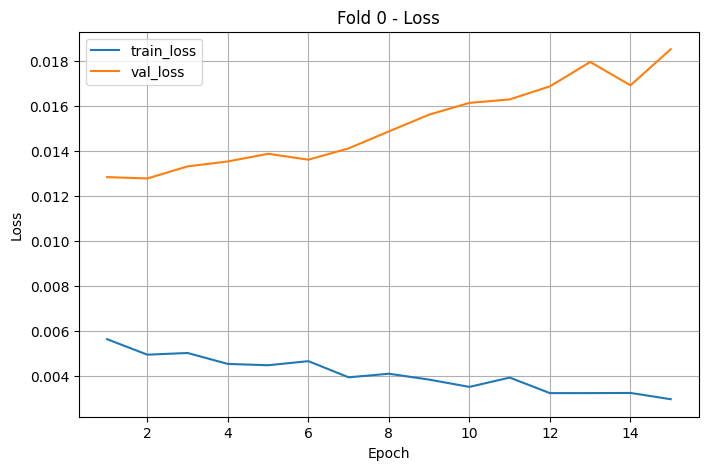

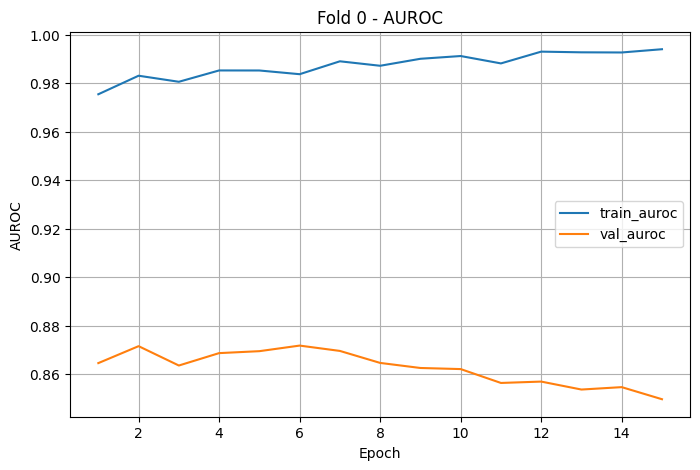

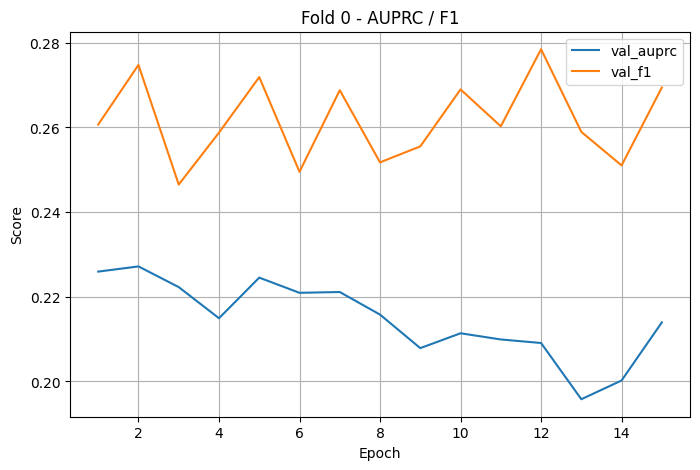

Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_0_loss.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_0_auroc.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_0_auprc_f1.png


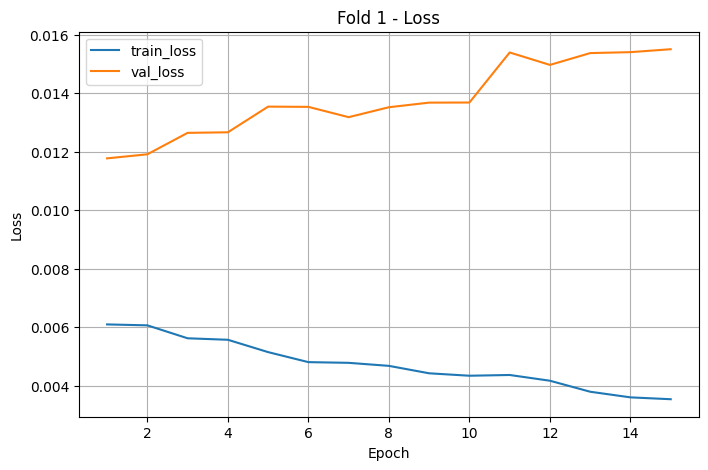

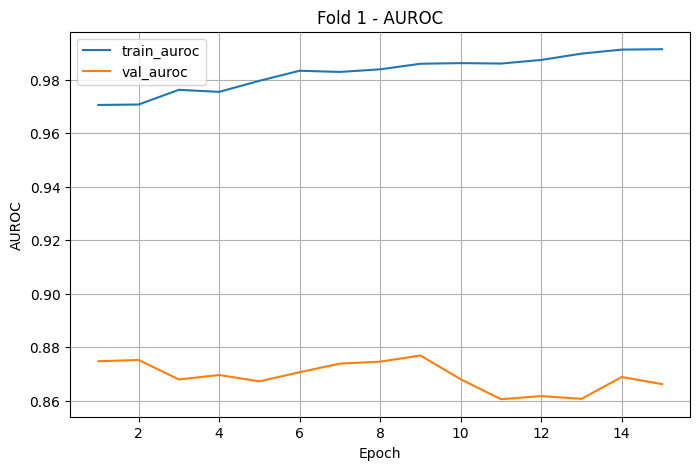

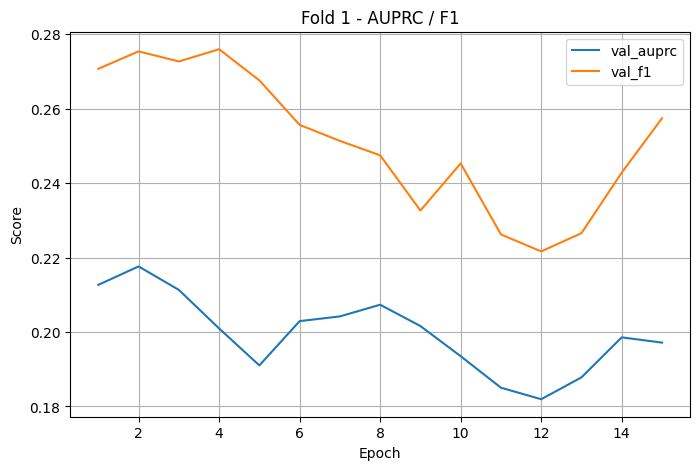

Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_1_loss.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_1_auroc.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_1_auprc_f1.png


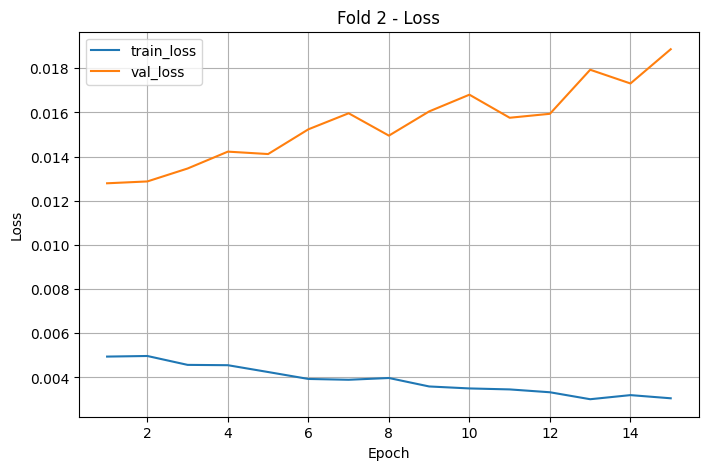

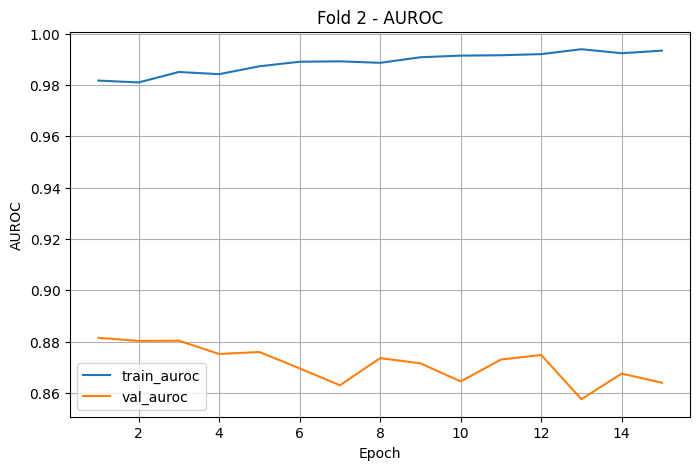

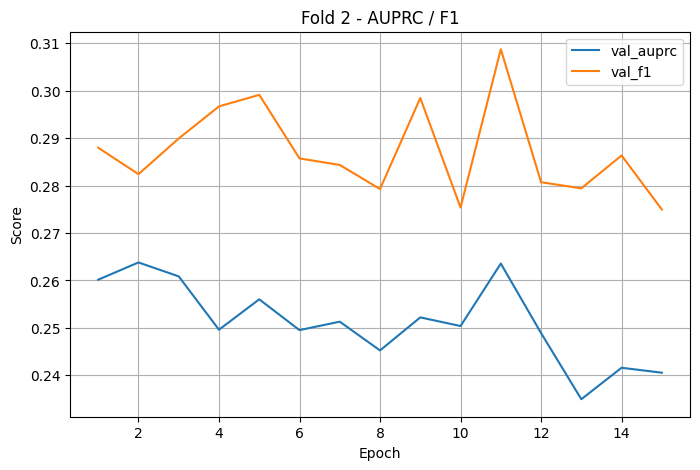

Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_2_loss.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_2_auroc.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_2_auprc_f1.png


In [22]:
for fold_idx in FOLDS_TO_RUN:
    history_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_history.csv"
    history_df = pd.read_csv(history_path)

    loss_plot_path  = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_loss.png"
    auroc_plot_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_auroc.png"
    score_plot_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_auprc_f1.png"

    # Loss
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="train_loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Fold {fold_idx} - Loss")
    plt.legend()
    plt.grid(True)
    plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # AUROC
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["train_auroc"], label="train_auroc")
    plt.plot(history_df["epoch"], history_df["val_auroc"], label="val_auroc")
    plt.xlabel("Epoch")
    plt.ylabel("AUROC")
    plt.title(f"Fold {fold_idx} - AUROC")
    plt.legend()
    plt.grid(True)
    plt.savefig(auroc_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    # AUPRC / F1
    plt.figure(figsize=(8, 5))
    plt.plot(history_df["epoch"], history_df["val_auprc"], label="val_auprc")
    plt.plot(history_df["epoch"], history_df["val_f1"], label="val_f1")
    plt.xlabel("Epoch")
    plt.ylabel("Score")
    plt.title(f"Fold {fold_idx} - AUPRC / F1")
    plt.legend()
    plt.grid(True)
    plt.savefig(score_plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close()

    print(f"Saved: {loss_plot_path}")
    print(f"Saved: {auroc_plot_path}")
    print(f"Saved: {score_plot_path}")

# OOF and TTA

In [23]:
USE_TTA_EVAL = False
WARMSTART_HYBRID = False

oof_probs = []
oof_labels = []
oof_records = []
fold_oof_results = []

for fold_idx, train_idx, val_idx in fold_splits:
    print(f"\n===== OOF evaluation fold {fold_idx} =====")

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    val_loader = make_val_loader(val_df, fold_idx=fold_idx)

    model = build_model(
        fold_idx=fold_idx, 
        use_all_dev_checkpoint=False, 
        warmstart_hybrid_from_frozen=WARMSTART_HYBRID)
    
    BEST_MODEL_PATH, _, _ = get_fold_paths(fold_idx)

    state_dict = torch.load(BEST_MODEL_PATH, map_location="cpu", weights_only=True)
    model.load_state_dict(state_dict)
    model = model.to(device)
    model.eval()

    criterion, _ = build_training_components(model, train_df)


    val_metrics = validate_one_epoch(
        model,
        val_loader,
        criterion,
        device,
        use_tta=USE_TTA_EVAL
    )

    fold_oof_results.append({
        "fold": fold_idx,
        "auroc": val_metrics["auroc"],
        "auprc": val_metrics["auprc"],
        "f1": val_metrics["f1"],
    })

    fold_probs = val_metrics["all_probs"]
    fold_labels = val_metrics["all_labels"]

    fold_pred_df = val_df[["image_name", "target"]].copy()
    fold_pred_df["fold"] = fold_idx
    fold_pred_df["prob"] = fold_probs
    fold_pred_df["pred_05"] = (fold_pred_df["prob"] >= 0.5).astype(int)

    fold_csv_path = WORKING_DIR / f"{EXPERIMENT_NAME}_fold_{fold_idx}_val_predictions.csv"
    fold_pred_df.to_csv(fold_csv_path, index=False)
    print(f"Saved: {fold_csv_path}")

    oof_records.append(fold_pred_df)
    oof_probs.extend(fold_probs)
    oof_labels.extend(fold_labels)

oof_probs = np.array(oof_probs)
oof_labels = np.array(oof_labels)

oof_pred_df = pd.concat(oof_records, axis=0, ignore_index=True)
oof_pred_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_predictions.csv"
oof_pred_df.to_csv(oof_pred_path, index=False)

oof_auroc = roc_auc_score(oof_labels, oof_probs)
oof_auprc = average_precision_score(oof_labels, oof_probs)


# Define the path for the OOF summary text file
oof_summary_txt_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_summary.txt"

# Open the file in write mode ("w")
with open(oof_summary_txt_path, "w") as f:
    
    # Log per-fold metrics
    title_fold = "===== Per-fold OOF metrics ====="
    print(f"\n{title_fold}")
    f.write(f"{title_fold}\n")
    
    for result in fold_oof_results:
        line = (
            f"Fold {result['fold']} | "
            f"AUROC: {result['auroc']:.4f} | "
            f"AUPRC: {result['auprc']:.4f} | "
            f"F1@0.5: {result['f1']:.4f}"
        )
        print(line)
        f.write(f"{line}\n")
        
    # Log global metrics
    title_global = "===== Global OOF metrics ====="
    print(f"\n{title_global}")
    f.write(f"\n{title_global}\n")
    
    line_auroc = f"OOF AUROC: {oof_auroc:.4f}"
    line_auprc = f"OOF AUPRC: {oof_auprc:.4f}"
    
    print(line_auroc)
    print(line_auprc)
    f.write(f"{line_auroc}\n")
    f.write(f"{line_auprc}\n")

# Console confirmation
print(f"\nSaved OOF metrics summary to: {oof_summary_txt_path}")

oof_threshold_df = threshold_sweep(oof_labels, oof_probs)
oof_threshold_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_threshold_sweep.csv"
oof_threshold_df.to_csv(oof_threshold_path, index=False)

display(oof_threshold_df)

best_idx = oof_threshold_df["f1"].idxmax()
best_row = oof_threshold_df.loc[best_idx]
best_thr = float(best_row["threshold"])

print("\nBest OOF threshold by F1:")
print(best_row)

# APPEND BEST THRESHOLD TO THE SUMMARY TXT

with open(oof_summary_txt_path, "a") as f:  
    f.write("\n===== Best OOF Threshold by F1 =====\n")
    f.write(f"Threshold: {best_thr:.4f}\n")
    f.write(f"F1 Score:  {best_row['f1']:.4f}\n")
    f.write(f"Precision: {best_row['precision']:.4f}\n")
    f.write(f"Recall:    {best_row['recall']:.4f}\n")

print(f"\nAppended best threshold metrics to: {oof_summary_txt_path}")



===== OOF evaluation fold 0 =====
Loaded offline weights from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded baseline CNN checkpoint from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_transfer_full_ft_FOCAL_alpha_075_3fold_TTA_AUPRC_30epochs_aug_fold_0_best_model.pth


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_0_val_predictions.csv

===== OOF evaluation fold 1 =====
Loaded offline weights from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded baseline CNN checkpoint from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_transfer_full_ft_FOCAL_alpha_075_3fold_TTA_AUPRC_30epochs_aug_fold_1_best_model.pth


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_1_val_predictions.csv

===== OOF evaluation fold 2 =====
Loaded offline weights from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_rwightman-7f5810bc.pth
Loaded baseline CNN checkpoint from /user/HS401/ep01372/Documents/AML_Project/inputs/efficientnet_b0_transfer_full_ft_FOCAL_alpha_075_3fold_TTA_AUPRC_30epochs_aug_fold_2_best_model.pth


/user/HS401/ep01372/Documents/AML_Project/venv/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_fold_2_val_predictions.csv

===== Per-fold OOF metrics =====
Fold 0 | AUROC: 0.8716 | AUPRC: 0.2272 | F1@0.5: 0.2748
Fold 1 | AUROC: 0.8752 | AUPRC: 0.2176 | F1@0.5: 0.2754
Fold 2 | AUROC: 0.8803 | AUPRC: 0.2638 | F1@0.5: 0.2824

===== Global OOF metrics =====
OOF AUROC: 0.8746
OOF AUPRC: 0.2307

Saved OOF metrics summary to: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_summary.txt


,threshold,precision,recall,f1,specificity
0,0.05,0.028449,0.964041,0.055267,0.409164
1,0.10,0.041986,0.900685,0.080232,0.631184
2,0.15,0.056701,0.847603,0.106292,0.746942
3,0.20,0.072654,0.775685,0.132864,0.822322
4,0.25,0.088465,0.698630,0.157044,0.870813
5,0.30,0.108211,0.631849,0.184777,0.906552
6,0.35,0.129468,0.558219,0.210187,0.932641
7,0.40,0.157247,0.481164,0.237031,0.953721
8,0.45,0.186804,0.402397,0.255157,0.968564
9,0.50,0.234393,0.340753,0.277739,0.980026



Best OOF threshold by F1:
threshold      0.550000
precision      0.287435
recall         0.285959
f1             0.286695
specificity    0.987278
Name: 10, dtype: float64

Appended best threshold metrics to: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_summary.txt


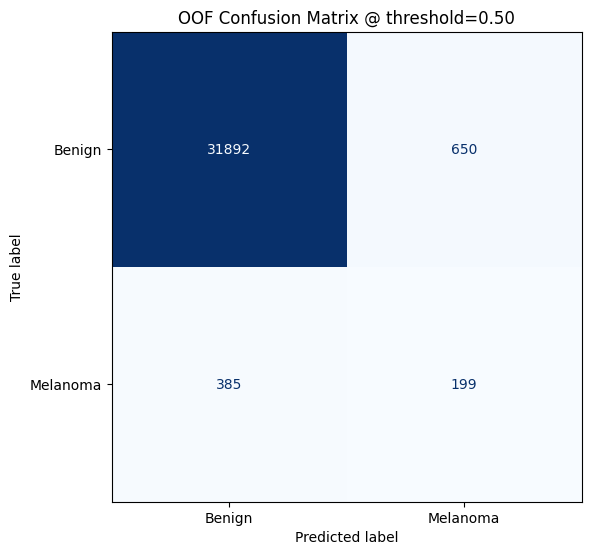

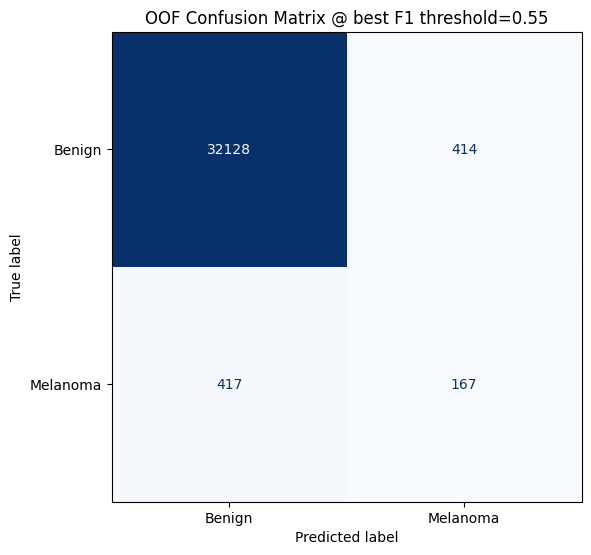


Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_predictions.csv
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_threshold_sweep.csv
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_confusion_matrix_t050.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_confusion_matrix_best_f1.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_metrics.json


In [24]:
def save_confusion_matrix_figure(y_true, y_prob, threshold, save_path, title):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    class_labels = ['Benign', 'Melanoma']

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "threshold": threshold,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
    }
    return metrics

cm_05_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_confusion_matrix_t050.png"
cm_best_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_confusion_matrix_best_f1.png"

cm_metrics_05 = save_confusion_matrix_figure(
    oof_labels,
    oof_probs,
    threshold=0.5,
    save_path=cm_05_path,
    title="OOF Confusion Matrix @ threshold=0.50"
)

cm_metrics_best = save_confusion_matrix_figure(
    oof_labels,
    oof_probs,
    threshold=best_thr,
    save_path=cm_best_path,
    title=f"OOF Confusion Matrix @ best F1 threshold={best_thr:.2f}"
)

oof_metrics = {
    "oof_auroc": float(oof_auroc),
    "oof_auprc": float(oof_auprc),
    "best_f1_threshold": best_thr,
    "cm_at_050": cm_metrics_05,
    "cm_at_best_f1": cm_metrics_best,
}

metrics_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_metrics.json"
with open(metrics_path, "w") as f:
    import json
    json.dump(oof_metrics, f, indent=2)

print(f"\nSaved: {oof_pred_path}")
print(f"Saved: {oof_threshold_path}")
print(f"Saved: {cm_05_path}")
print(f"Saved: {cm_best_path}")
print(f"Saved: {metrics_path}")

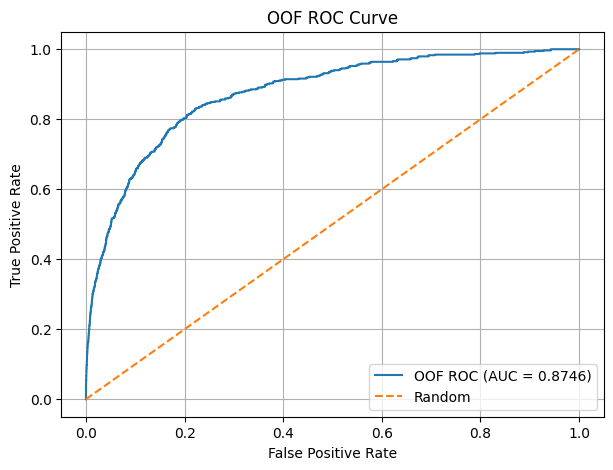

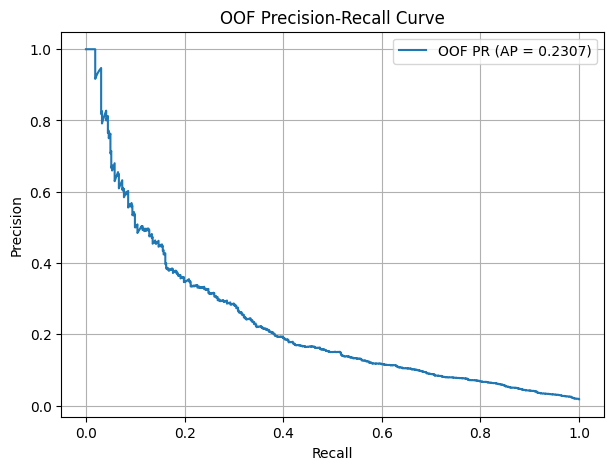

Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_roc.png
Saved: /user/HS401/ep01372/Documents/AML_Project/outputs/efficientNet_b0_custom_transferKaggleCNN_ViT_residualGated_fullCNN_3folds_OOF_AUPRC_v1_oof_pr.png


In [25]:
roc_path = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_roc.png"
pr_path  = WORKING_DIR / f"{EXPERIMENT_NAME}_oof_pr.png"


fpr, tpr, _ = roc_curve(oof_labels, oof_probs)
precision_pr, recall_pr, _ = precision_recall_curve(oof_labels, oof_probs)

roc_auc = oof_auroc
ap = oof_auprc

# ROC
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"OOF ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("OOF ROC Curve")
plt.legend()
plt.grid(True)
plt.savefig(roc_path, bbox_inches="tight")
plt.show()

# PR
plt.figure(figsize=(7, 5))
plt.plot(recall_pr, precision_pr, label=f"OOF PR (AP = {ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("OOF Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.savefig(pr_path, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)
print("Saved:", pr_path)